Dataset Head:
  Rank       Country  Proven_reserves  Production   Consumption    Exports   \
0    1     Venezuela     298350000000    3023000.0      571000.0  2452000.0   
1    2  Saudi Arabia     267900000000    9684700.0     2817000.0  6880000.0   
2    3        Canada     173100000000    3324300.0     2259000.0  1576000.0   
3    4          Iran     154600000000    3113300.0     1709000.0  2445000.0   
4    5          Iraq     141400000000    3054400.0      818000.0  2390000.0   

   Imports   
0       0.0  
1       0.0  
2  770300.0  
3   15600.0  
4       0.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             210 non-null    object 
 1   Country          210 non-null    object 
 2   Proven_reserves  210 non-null    int64  
 3   Production       207 non-null    float64
 4   Consumption      207 non-nu

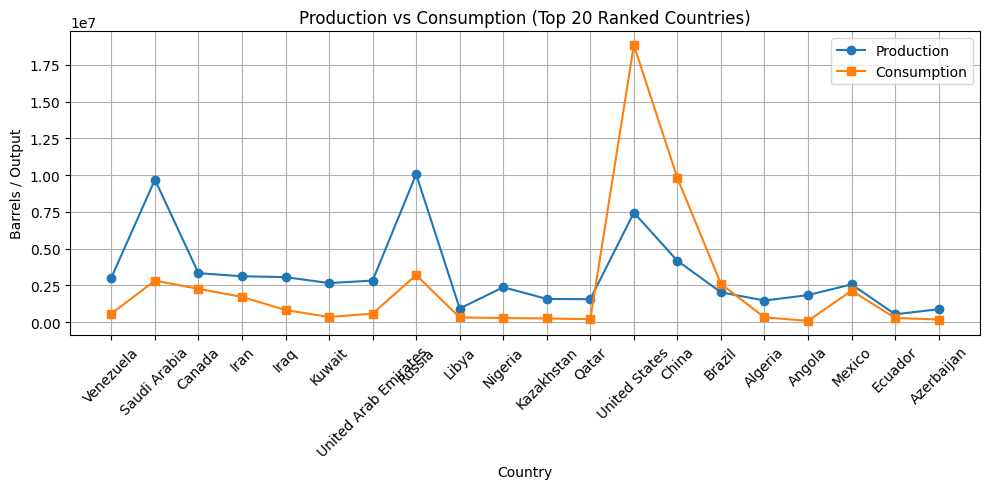

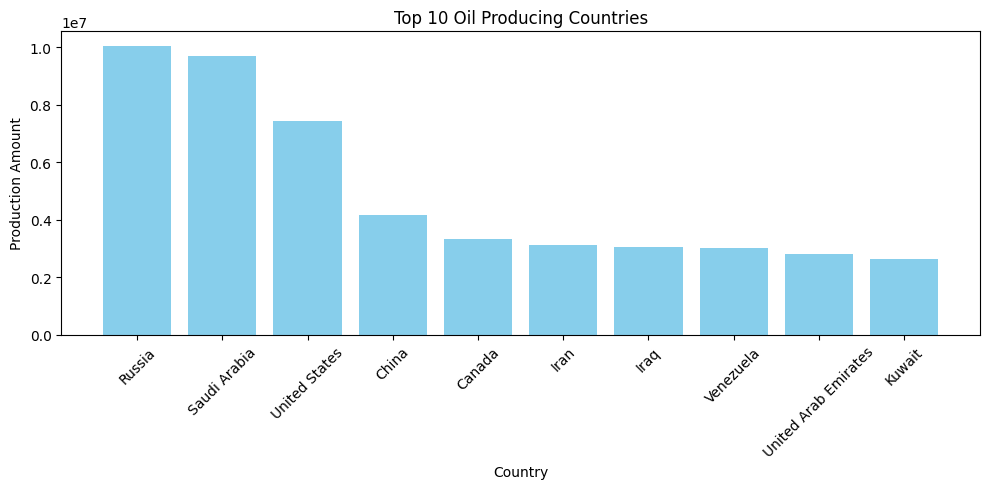

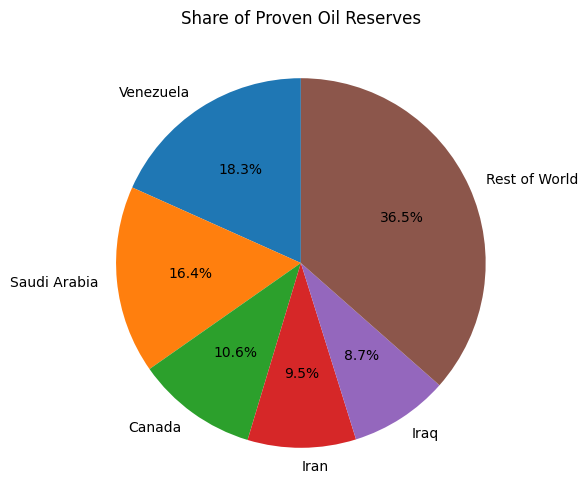

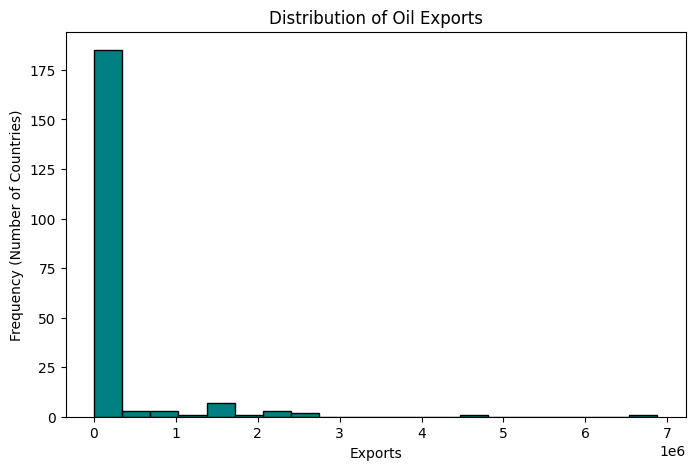

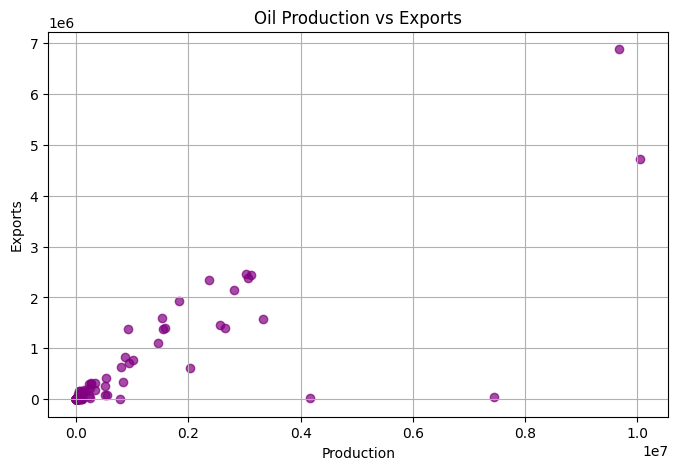

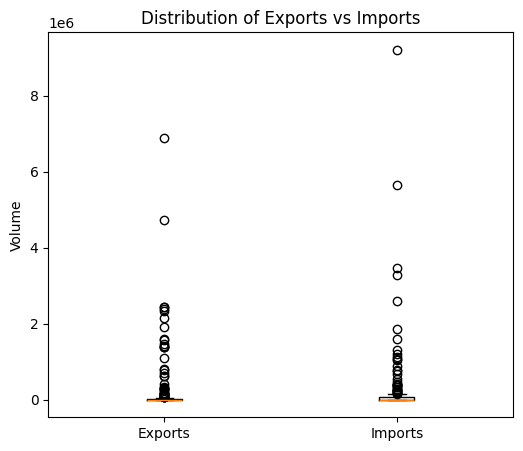

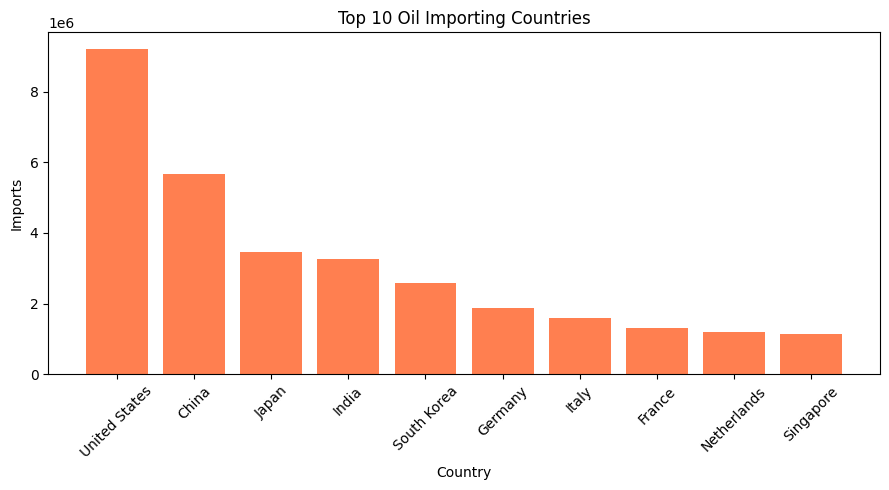

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD DATASET
# ---------------------------------------------------------
# Uncomment if using Google Colab:
# from google.colab import files
# uploaded = files.upload()

# Load dataset (replace 'oil_by_country.csv' with your file name)
df = pd.read_csv("/content/oil_by_country.csv")

# Display basic structure and check for missing values
print("Dataset Head:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Create a copy for processing
data = df.copy()

# ---------------------------------------------------------
# 2. PREPROCESSING
# ---------------------------------------------------------
# Strip whitespace from column names just in case
data.columns = data.columns.str.strip()

# List of numeric columns to clean (remove commas, spaces, or non-numeric symbols if loaded as text)
numeric_cols = ['Rank', 'Proven_reserves', 'Production', 'Consumption', 'Exports', 'Imports']

for col in numeric_cols:
    if col in data.columns and data[col].dtype == 'object':
        data[col] = data[col].str.replace(',', '').str.extract(r'([\d.]+)').astype(float)

# Filter out aggregate regions or global totals if they exist in the Country column
data = data[~data['Country'].isin(['World', 'Total', 'Global', 'OECD', 'EU'])]

# ---------------------------------------------------------
# 3. VISUALIZATIONS
# ---------------------------------------------------------

# 1. Line Plot (Production vs. Consumption by Country Rank)
plt.figure(figsize=(10, 5))
ranked_data = data.sort_values('Rank').head(20)
plt.plot(ranked_data['Country'], ranked_data['Production'], marker='o', label='Production')
plt.plot(ranked_data['Country'], ranked_data['Consumption'], marker='s', label='Consumption')
plt.title('Production vs Consumption (Top 20 Ranked Countries)')
plt.xlabel('Country')
plt.ylabel('Barrels / Output')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Bar Plot (Top 10 Countries by Production)
top_producers = data.sort_values(by='Production', ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_producers['Country'], top_producers['Production'], color='skyblue')
plt.title('Top 10 Oil Producing Countries')
plt.xlabel('Country')
plt.ylabel('Production Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Pie Chart (Global Share of Proven Reserves)
top_reserves = data.sort_values(by='Proven_reserves', ascending=False)
top5_reserves = top_reserves.head(5)
other_reserves = top_reserves.iloc[5:]['Proven_reserves'].sum()

labels = list(top5_reserves['Country']) + ['Rest of World']
values = list(top5_reserves['Proven_reserves']) + [other_reserves]

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Share of Proven Oil Reserves')
plt.show()

# 4. Histogram (Distribution of Exports)
plt.figure(figsize=(8, 5))
plt.hist(data['Exports'].dropna(), bins=20, color='teal', edgecolor='black')
plt.title('Distribution of Oil Exports')
plt.xlabel('Exports')
plt.ylabel('Frequency (Number of Countries)')
plt.show()

# 5. Scatter Plot (Production vs. Exports)
plt.figure(figsize=(8, 5))
plt.scatter(data['Production'], data['Exports'], color='purple', alpha=0.7)
plt.title('Oil Production vs Exports')
plt.xlabel('Production')
plt.ylabel('Exports')
plt.grid(True)
plt.show()

# 6. Box Plot (Comparing Trade Distributions)
plt.figure(figsize=(6, 5))
plt.boxplot([data['Exports'].dropna(), data['Imports'].dropna()], tick_labels=['Exports', 'Imports'])
plt.title('Distribution of Exports vs Imports')
plt.ylabel('Volume')
plt.show()

# 7. Bar Plot (Top 10 Oil Importers)
top_importers = data.sort_values(by='Imports', ascending=False).head(10)
plt.figure(figsize=(9, 5))
plt.bar(top_importers['Country'], top_importers['Imports'], color='coral')
plt.title('Top 10 Oil Importing Countries')
plt.xlabel('Country')
plt.ylabel('Imports')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()